# ⚡ VoltVision — EV Purchase Prediction | Baseline

This is the **baseline notebook** for our VoltVision EV Purchase Prediction project. ⚡

The goal here is intentionally simple: build a clean first benchmark before doing any advanced optimization.

We will do **basic EDA, a small amount of feature engineering, simple encoding, train multiple strong baseline classifiers, compare them with ROC-AUC, and create our first Kaggle submission**.

No hyperparameter tuning, cross-validation, stacking, target encoding, SHAP, or advanced feature engineering will be used here. Those belong to later notebooks.

## Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , roc_auc_score
from sklearn.base import clone

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier , HistGradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42

In [2]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
sample_submission = pd.read_csv("../data/sample_submission.csv")

train.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [3]:
test.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,668665,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,Yes,No,Low
1,668666,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,No,No,Low
2,668667,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,No,No,Low
3,668668,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,Yes,No,Low
4,668669,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,Yes,Yes,Low


In [5]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (668665, 15)
Test shape: (286571, 14)
Sample submission shape: (286571, 2)


Okay, the files are loaded successfully. ✅

The training data contains **668,665 rows and 15 columns**, while the test data contains **286,571 rows and 14 columns**. The extra training column is our target: `Will_Buy_EV`.

This is a large-row, low-dimensional tabular classification problem, which is perfect for establishing a strong baseline with several classical and boosting models.

## Basic Dataset Overview

In [6]:
train.columns

Index(['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender',
       'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='object')

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,668665.0,334332.000000,193027.103211,0.0,167166.0,334332.0,501498.0,668664.0
Age,668665.0,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0


In [9]:
train.describe(include="object").T

,count,unique,top,freq
Gender,668665,3,Male,367954
City_Type,668665,3,Urban,289305
Current_Car_Type,668665,4,Sedan,303459
Home_Charging_Possible,668665,2,Yes,462677
Subsidy_Available,668665,2,Yes,419909
Range_Anxiety_Level,668665,3,Low,603972
Will_Buy_EV,668665,2,No,551886


Nice — the feature space is compact and easy to interpret. We have demographic, income, commute, vehicle ownership, charging infrastructure, environmental concern, subsidy, and range-anxiety information.

Most categorical variables also have very low cardinality, so a simple one-hot encoding baseline is completely reasonable here.

## Data Quality Check

In [10]:
missing = train.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

In [11]:
print("Train missing values:", train.isnull().sum().sum())
print("Test missing values:", test.isnull().sum().sum())
print("Train duplicate rows:", train.duplicated().sum())
print("Test duplicate rows:", test.duplicated().sum())

Train missing values: 0
Test missing values: 0
Train duplicate rows: 0
Test duplicate rows: 0


In [12]:
categorical_cols = train.drop(columns="Will_Buy_EV").select_dtypes(include="object").columns
numerical_cols = train.drop(columns="Will_Buy_EV").select_dtypes(include=np.number).columns

print("Numerical columns:", len(numerical_cols))
print("Categorical columns:", len(categorical_cols))

Numerical columns: 8
Categorical columns: 6


In [13]:
train[categorical_cols].nunique().sort_values()

Home_Charging_Possible    2
Subsidy_Available         2
City_Type                 3
Gender                    3
Range_Anxiety_Level       3
Current_Car_Type          4
dtype: int64

Good news — the dataset is already very clean. ✅

There are **0 missing values and 0 exact duplicate rows** in both train and test. That means our baseline does not need imputation or duplicate handling.

The categorical columns are all low-cardinality, so we can keep preprocessing simple instead of adding unnecessary complexity.

## Target Analysis

In [14]:
train["Will_Buy_EV"].value_counts()

Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64

In [15]:
target_percent = train["Will_Buy_EV"].value_counts(normalize=True).mul(100).round(2)
target_percent

Will_Buy_EV
No     82.54
Yes    17.46
Name: proportion, dtype: float64

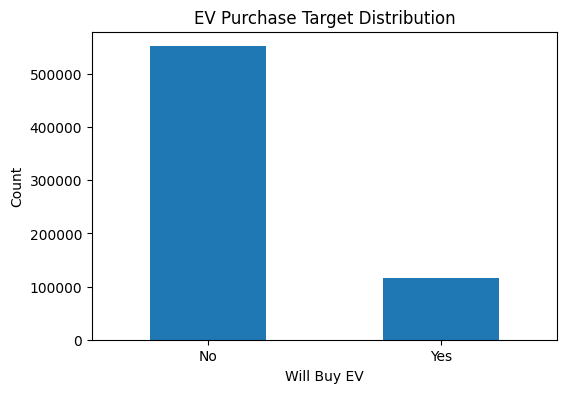

In [16]:
target_counts = train["Will_Buy_EV"].value_counts()

plt.figure(figsize=(6,4))
target_counts.plot(kind="bar")
plt.title("EV Purchase Target Distribution")
plt.xlabel("Will Buy EV")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

The target is clearly imbalanced: about **82.54% are No** and **17.46% are Yes**.

That is why **ROC-AUC will be our primary metric**. Accuracy can still be reported for context, but a model predicting mostly the majority class could look deceptively good on accuracy alone.

## Basic Feature Analysis

In [17]:
target_rate_by_subsidy = pd.crosstab(train["Subsidy_Available"] , train["Will_Buy_EV"] , normalize="index").mul(100).round(2)
target_rate_by_subsidy

Will_Buy_EV,No,Yes
Subsidy_Available,,
No,99.42,0.58
Yes,72.53,27.47


In [18]:
target_rate_by_anxiety = pd.crosstab(train["Range_Anxiety_Level"] , train["Will_Buy_EV"] , normalize="index").mul(100).round(2)
target_rate_by_anxiety

Will_Buy_EV,No,Yes
Range_Anxiety_Level,,
High,99.86,0.14
Low,81.10,18.90
Medium,95.83,4.17


In [19]:
target_rate_by_charging = pd.crosstab(train["Home_Charging_Possible"] , train["Will_Buy_EV"] , normalize="index").mul(100).round(2)
target_rate_by_charging

Will_Buy_EV,No,Yes
Home_Charging_Possible,,
No,87.29,12.71
Yes,80.42,19.58


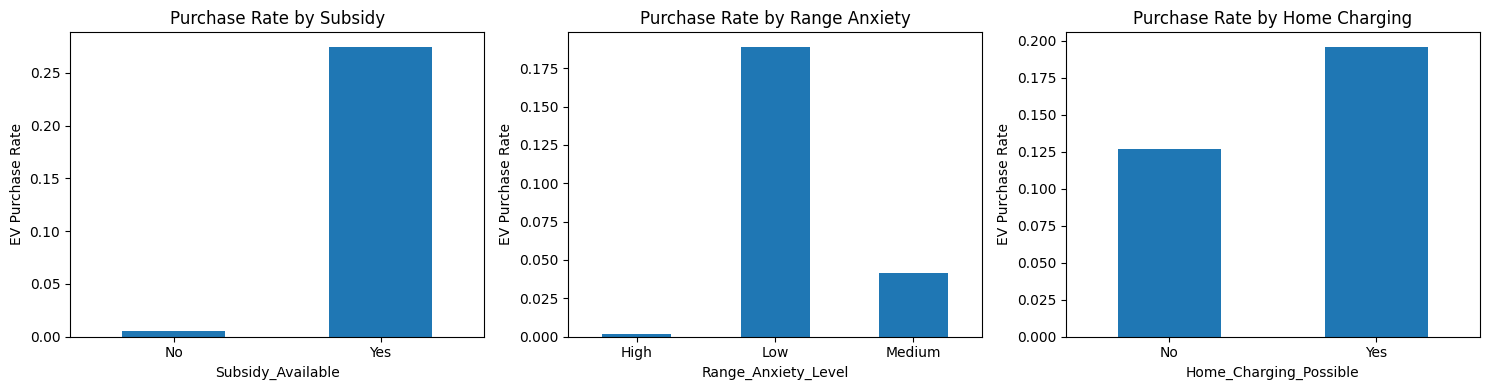

In [20]:
subsidy_rate = train.assign(Target=(train["Will_Buy_EV"] == "Yes").astype(int)).groupby("Subsidy_Available")["Target"].mean()
anxiety_rate = train.assign(Target=(train["Will_Buy_EV"] == "Yes").astype(int)).groupby("Range_Anxiety_Level")["Target"].mean()
charging_rate = train.assign(Target=(train["Will_Buy_EV"] == "Yes").astype(int)).groupby("Home_Charging_Possible")["Target"].mean()

fig , axes = plt.subplots(1 , 3 , figsize=(15,4))

subsidy_rate.plot(kind="bar" , ax=axes[0])
anxiety_rate.plot(kind="bar" , ax=axes[1])
charging_rate.plot(kind="bar" , ax=axes[2])

axes[0].set_title("Purchase Rate by Subsidy")
axes[1].set_title("Purchase Rate by Range Anxiety")
axes[2].set_title("Purchase Rate by Home Charging")

axes[0].set_ylabel("EV Purchase Rate")
axes[1].set_ylabel("EV Purchase Rate")
axes[2].set_ylabel("EV Purchase Rate")

for ax in axes:
    ax.tick_params(axis="x" , rotation=0)

plt.tight_layout()
plt.show()

In [21]:
train.groupby("Will_Buy_EV")[[
    "Age" , "Annual_Income_USD" , "Daily_Commute_km" ,
    "Number_of_Cars_Owned" , "Charging_Stations_Near_Home" ,
    "Charging_Stations_Near_Work" , "Environmental_Concern_Level"
]].mean().round(2)

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
Will_Buy_EV,,,,,,,
No,47.08,81794.59,32.55,1.71,4.99,7.21,2.63
Yes,46.83,98827.30,30.29,1.72,4.82,7.04,4.38


Even this basic analysis already shows useful signal.

`Subsidy_Available` creates a very large separation in purchase rate, while lower range anxiety and home-charging access are also associated with higher EV purchase probability. Environmental concern and income show meaningful numerical differences between the two target groups as well.

For the baseline, we will stop here instead of turning EDA into a full research notebook.

## Basic Feature Engineering

In [22]:
train_model = train.copy()
test_model = test.copy()

train_model["Total_Charging_Stations"] = train_model["Charging_Stations_Near_Home"] + train_model["Charging_Stations_Near_Work"]
test_model["Total_Charging_Stations"] = test_model["Charging_Stations_Near_Home"] + test_model["Charging_Stations_Near_Work"]

train_model["Income_Per_Car"] = train_model["Annual_Income_USD"] / train_model["Number_of_Cars_Owned"]
test_model["Income_Per_Car"] = test_model["Annual_Income_USD"] / test_model["Number_of_Cars_Owned"]

train_model[["Total_Charging_Stations" , "Income_Per_Car"]].head()

,Total_Charging_Stations,Income_Per_Car
0,10,46443.5
1,4,30000.0
2,23,94389.0
3,15,36790.0
4,5,57898.0


We only created **two intuitive baseline features**:

- `Total_Charging_Stations` combines charging availability near home and work.
- `Income_Per_Car` gives a rough affordability signal relative to current vehicle ownership.

These are simple domain-based features. We are intentionally avoiding interactions, bins, target statistics, clustering, and other advanced transformations in the baseline.

## Target and Categorical Encoding

In [23]:
test_ids = test_model["id"].copy()

y = train_model["Will_Buy_EV"].map({"No":0 , "Yes":1})
X = train_model.drop(columns=["id" , "Will_Buy_EV"])
X_kaggle = test_model.drop(columns="id")

X.shape , X_kaggle.shape , y.shape

((668665, 15), (286571, 15), (668665,))

In [24]:
categorical_cols = X.select_dtypes(include="object").columns
categorical_cols

Index(['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level'],
      dtype='object')

In [25]:
X = pd.get_dummies(X , columns=categorical_cols , drop_first=False , dtype=int)
X_kaggle = pd.get_dummies(X_kaggle , columns=categorical_cols , drop_first=False , dtype=int)

X_kaggle = X_kaggle.reindex(columns=X.columns , fill_value=0)

X.shape , X_kaggle.shape

((668665, 26), (286571, 26))

In [26]:
print("Training missing values:", X.isnull().sum().sum())
print("Kaggle test missing values:", X_kaggle.isnull().sum().sum())
print("Feature columns match:", X.columns.equals(X_kaggle.columns))

Training missing values: 0
Kaggle test missing values: 0
Feature columns match: True


Great — the target is now binary and the categorical features are one-hot encoded. ✅

We also aligned the Kaggle test columns with the training columns, so the models will receive exactly the same feature structure at prediction time.

## Train / Validation Split

In [27]:
X_train , X_valid , y_train , y_valid = train_test_split(
    X , y , test_size=0.2 , random_state=RANDOM_STATE , stratify=y
)

X_train.shape , X_valid.shape , y_train.shape , y_valid.shape

((534932, 26), (133733, 26), (534932,), (133733,))

In [28]:
print("Train positive rate:", round(y_train.mean() * 100 , 2))
print("Validation positive rate:", round(y_valid.mean() * 100 , 2))

Train positive rate: 17.46
Validation positive rate: 17.46


The split is stratified, so the EV-purchase rate stays almost identical in training and validation.

For this first baseline, a single clean holdout validation set is enough. We will use cross-validation later when we start serious model selection and tuning.

## Baseline Models

We will test a broad set of **reasonable tabular classifiers**. We are not including models like KNN or kernel SVM because they are unnecessarily expensive on more than half a million training rows and are not competitive choices for this dataset.

In [29]:
results = []
trained_models = {}

### Dummy Classifier

In [30]:
start = time.time()

dummy_model = DummyClassifier(strategy="prior")
dummy_model.fit(X_train , y_train)

dummy_pred = dummy_model.predict(X_valid)
dummy_prob = dummy_model.predict_proba(X_valid)[:,1]

results.append([
    "Dummy" ,
    accuracy_score(y_valid,dummy_pred) ,
    precision_score(y_valid,dummy_pred,zero_division=0) ,
    recall_score(y_valid,dummy_pred,zero_division=0) ,
    f1_score(y_valid,dummy_pred,zero_division=0) ,
    roc_auc_score(y_valid,dummy_prob) ,
    time.time() - start
])

trained_models["Dummy"] = dummy_model

The Dummy model is our true reference point. Its ROC-AUC should be around **0.50**, which tells us what performance looks like when the model has no useful ranking ability.

### Logistic Regression

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

start = time.time()

logistic_model = LogisticRegression(max_iter=1000 , random_state=RANDOM_STATE)
logistic_model.fit(X_train_scaled , y_train)

logistic_pred = logistic_model.predict(X_valid_scaled)
logistic_prob = logistic_model.predict_proba(X_valid_scaled)[:,1]

results.append([
    "Logistic Regression" ,
    accuracy_score(y_valid,logistic_pred) ,
    precision_score(y_valid,logistic_pred,zero_division=0) ,
    recall_score(y_valid,logistic_pred,zero_division=0) ,
    f1_score(y_valid,logistic_pred,zero_division=0) ,
    roc_auc_score(y_valid,logistic_prob) ,
    time.time() - start
])

trained_models["Logistic Regression"] = logistic_model

Logistic Regression gives us a strong **linear baseline**. If it performs well, that means a large amount of the signal can already be captured with relatively simple additive relationships.

### Decision Tree

In [32]:
start = time.time()

tree_model = DecisionTreeClassifier(max_depth=12 , min_samples_split=20 , random_state=RANDOM_STATE)
tree_model.fit(X_train , y_train)

tree_pred = tree_model.predict(X_valid)
tree_prob = tree_model.predict_proba(X_valid)[:,1]

results.append([
    "Decision Tree" ,
    accuracy_score(y_valid,tree_pred) ,
    precision_score(y_valid,tree_pred,zero_division=0) ,
    recall_score(y_valid,tree_pred,zero_division=0) ,
    f1_score(y_valid,tree_pred,zero_division=0) ,
    roc_auc_score(y_valid,tree_prob) ,
    time.time() - start
])

trained_models["Decision Tree"] = tree_model

In [33]:
print("Train Accuracy:", round(tree_model.score(X_train , y_train) , 4))
print("Validation Accuracy:", round(tree_model.score(X_valid , y_valid) , 4))

Train Accuracy: 0.9003
Validation Accuracy: 0.8961


The Decision Tree is our first nonlinear model. The train-versus-validation accuracy comparison gives us a quick baseline check for overfitting without doing any tuning yet.

### Random Forest

In [34]:
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=150 , max_depth=18 , min_samples_split=10 ,
    random_state=RANDOM_STATE , n_jobs=-1
)
rf_model.fit(X_train , y_train)

rf_pred = rf_model.predict(X_valid)
rf_prob = rf_model.predict_proba(X_valid)[:,1]

results.append([
    "Random Forest" ,
    accuracy_score(y_valid,rf_pred) ,
    precision_score(y_valid,rf_pred,zero_division=0) ,
    recall_score(y_valid,rf_pred,zero_division=0) ,
    f1_score(y_valid,rf_pred,zero_division=0) ,
    roc_auc_score(y_valid,rf_prob) ,
    time.time() - start
])

trained_models["Random Forest"] = rf_model

### Extra Trees

In [35]:
start = time.time()

extra_model = ExtraTreesClassifier(
    n_estimators=150 , max_depth=18 , min_samples_split=10 ,
    random_state=RANDOM_STATE , n_jobs=-1
)
extra_model.fit(X_train , y_train)

extra_pred = extra_model.predict(X_valid)
extra_prob = extra_model.predict_proba(X_valid)[:,1]

results.append([
    "Extra Trees" ,
    accuracy_score(y_valid,extra_pred) ,
    precision_score(y_valid,extra_pred,zero_division=0) ,
    recall_score(y_valid,extra_pred,zero_division=0) ,
    f1_score(y_valid,extra_pred,zero_division=0) ,
    roc_auc_score(y_valid,extra_prob) ,
    time.time() - start
])

trained_models["Extra Trees"] = extra_model

Random Forest and Extra Trees give us two strong bagged-tree baselines. They can capture nonlinear interactions while still remaining straightforward and robust.

### AdaBoost

In [36]:
start = time.time()

ada_model = AdaBoostClassifier(n_estimators=100 , learning_rate=0.08 , random_state=RANDOM_STATE)
ada_model.fit(X_train , y_train)

ada_pred = ada_model.predict(X_valid)
ada_prob = ada_model.predict_proba(X_valid)[:,1]

results.append([
    "AdaBoost" ,
    accuracy_score(y_valid,ada_pred) ,
    precision_score(y_valid,ada_pred,zero_division=0) ,
    recall_score(y_valid,ada_pred,zero_division=0) ,
    f1_score(y_valid,ada_pred,zero_division=0) ,
    roc_auc_score(y_valid,ada_prob) ,
    time.time() - start
])

trained_models["AdaBoost"] = ada_model

### HistGradientBoosting

In [37]:
start = time.time()

hist_model = HistGradientBoostingClassifier(
    max_iter=150 , learning_rate=0.08 , max_leaf_nodes=31 , random_state=RANDOM_STATE
)
hist_model.fit(X_train , y_train)

hist_pred = hist_model.predict(X_valid)
hist_prob = hist_model.predict_proba(X_valid)[:,1]

results.append([
    "HistGradientBoosting" ,
    accuracy_score(y_valid,hist_pred) ,
    precision_score(y_valid,hist_pred,zero_division=0) ,
    recall_score(y_valid,hist_pred,zero_division=0) ,
    f1_score(y_valid,hist_pred,zero_division=0) ,
    roc_auc_score(y_valid,hist_prob) ,
    time.time() - start
])

trained_models["HistGradientBoosting"] = hist_model

Now we have two boosting-style sklearn baselines. HistGradientBoosting is especially useful here because it is designed to scale much better than the older classical GradientBoosting implementation on large tabular datasets.

### XGBoost

In [38]:
start = time.time()

xgb_model = XGBClassifier(
    n_estimators=250 , learning_rate=0.05 , max_depth=6 ,
    subsample=0.9 , colsample_bytree=0.9 ,
    eval_metric="auc" , random_state=RANDOM_STATE , n_jobs=-1
)
xgb_model.fit(X_train , y_train)

xgb_pred = xgb_model.predict(X_valid)
xgb_prob = xgb_model.predict_proba(X_valid)[:,1]

results.append([
    "XGBoost" ,
    accuracy_score(y_valid,xgb_pred) ,
    precision_score(y_valid,xgb_pred,zero_division=0) ,
    recall_score(y_valid,xgb_pred,zero_division=0) ,
    f1_score(y_valid,xgb_pred,zero_division=0) ,
    roc_auc_score(y_valid,xgb_prob) ,
    time.time() - start
])

trained_models["XGBoost"] = xgb_model

### LightGBM

In [39]:
start = time.time()

lgbm_model = LGBMClassifier(
    n_estimators=250 , learning_rate=0.05 , num_leaves=31 ,
    subsample=0.9 , colsample_bytree=0.9 ,
    random_state=RANDOM_STATE , n_jobs=-1 , verbosity=-1
)
lgbm_model.fit(X_train , y_train)

lgbm_pred = lgbm_model.predict(X_valid)
lgbm_prob = lgbm_model.predict_proba(X_valid)[:,1]

results.append([
    "LightGBM" ,
    accuracy_score(y_valid,lgbm_pred) ,
    precision_score(y_valid,lgbm_pred,zero_division=0) ,
    recall_score(y_valid,lgbm_pred,zero_division=0) ,
    f1_score(y_valid,lgbm_pred,zero_division=0) ,
    roc_auc_score(y_valid,lgbm_prob) ,
    time.time() - start
])

trained_models["LightGBM"] = lgbm_model

### CatBoost

In [40]:
start = time.time()

cat_model = CatBoostClassifier(
    iterations=250 , learning_rate=0.05 , depth=6 ,
    loss_function="Logloss" , eval_metric="AUC" ,
    random_seed=RANDOM_STATE , verbose=0
)
cat_model.fit(X_train , y_train)

cat_pred = cat_model.predict(X_valid).astype(int).ravel()
cat_prob = cat_model.predict_proba(X_valid)[:,1]

results.append([
    "CatBoost" ,
    accuracy_score(y_valid,cat_pred) ,
    precision_score(y_valid,cat_pred,zero_division=0) ,
    recall_score(y_valid,cat_pred,zero_division=0) ,
    f1_score(y_valid,cat_pred,zero_division=0) ,
    roc_auc_score(y_valid,cat_prob) ,
    time.time() - start
])

trained_models["CatBoost"] = cat_model

XGBoost, LightGBM, and CatBoost are our strongest modern tree-boosting baselines. We are still using simple, untuned configurations here — the purpose is to find a reliable starting point, not squeeze out the final leaderboard score yet.

## Model Comparison

In [41]:
results_df = pd.DataFrame(
    results ,
    columns=["Model" , "Accuracy" , "Precision" , "Recall" , "F1" , "ROC-AUC" , "Training Time (s)"]
)

results_df = results_df.sort_values("ROC-AUC" , ascending=False).reset_index(drop=True)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,LightGBM,0.8980,0.7242,0.6720,0.6971,0.9414,1.4673
1,XGBoost,0.8979,0.7258,0.6679,0.6956,0.9413,2.3482
2,HistGradientBoosting,0.8978,0.7251,0.6681,0.6954,0.9410,4.5469
3,CatBoost,0.8971,0.7257,0.6606,0.6917,0.9405,4.4265
4,Random Forest,0.8970,0.7281,0.6549,0.6895,0.9385,10.8707
5,Extra Trees,0.8952,0.7257,0.6425,0.6816,0.9380,9.8588
6,Logistic Regression,0.8948,0.7164,0.6586,0.6863,0.9380,0.4348
7,Decision Tree,0.8961,0.7172,0.6685,0.6920,0.9358,2.2605
8,AdaBoost,0.8254,0.0000,0.0000,0.0000,0.9151,34.5992
9,Dummy,0.8254,0.0000,0.0000,0.0000,0.5000,0.0983


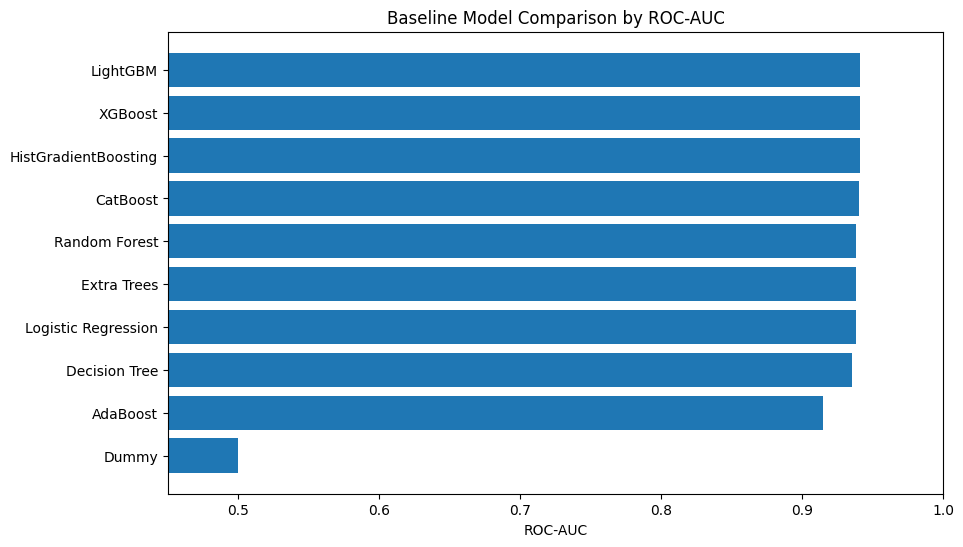

In [42]:
plot_df = results_df.sort_values("ROC-AUC")

plt.figure(figsize=(10,6))
plt.barh(plot_df["Model"] , plot_df["ROC-AUC"])
plt.title("Baseline Model Comparison by ROC-AUC")
plt.xlabel("ROC-AUC")
plt.xlim(0.45,1)
plt.show()

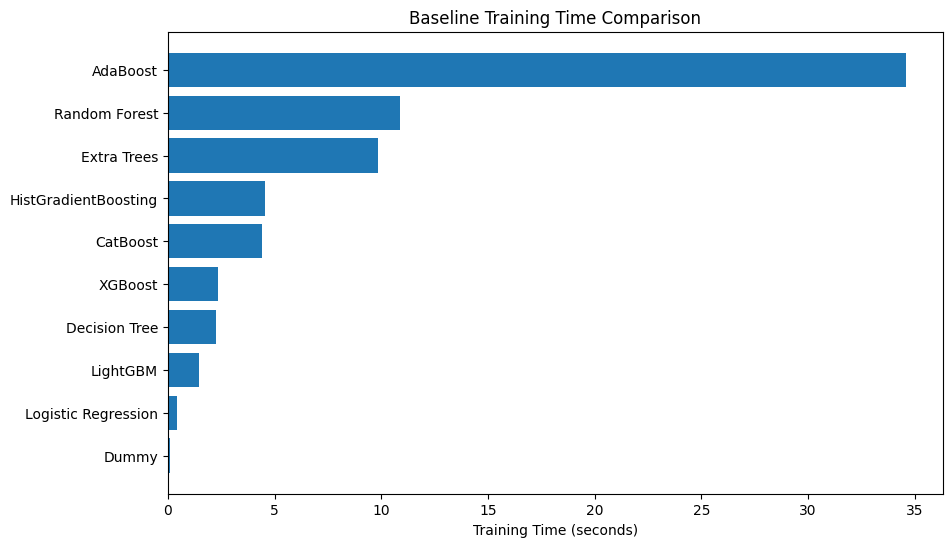

In [43]:
plot_df = results_df.sort_values("Training Time (s)")

plt.figure(figsize=(10,6))
plt.barh(plot_df["Model"] , plot_df["Training Time (s)"])
plt.title("Baseline Training Time Comparison")
plt.xlabel("Training Time (seconds)")
plt.show()

This table is our main baseline benchmark. 🎯

We sort by **ROC-AUC**, because that is the Kaggle competition metric. The additional precision, recall, F1, accuracy, and training-time columns help us understand the trade-offs, but they will not replace ROC-AUC when choosing the first submission model.

## Best Baseline Model

In [44]:
best_model_name = results_df.iloc[0]["Model"]
best_auc = results_df.iloc[0]["ROC-AUC"]

print("Best baseline model:", best_model_name)
print("Validation ROC-AUC:", round(best_auc , 5))

Best baseline model: LightGBM
Validation ROC-AUC: 0.94135


The best validation model becomes our **baseline submission model**.

We are not tuning it yet. This score is the benchmark that all future feature engineering, validation strategies, tuning, and ensembles will have to beat.

## Train Best Model on Full Data

In [45]:
best_model = trained_models[best_model_name]
final_model = clone(best_model)

if best_model_name == "Logistic Regression":
    full_scaler = StandardScaler()
    X_full_scaled = full_scaler.fit_transform(X)
    X_kaggle_scaled = full_scaler.transform(X_kaggle)

    final_model.fit(X_full_scaled , y)
    test_prob = final_model.predict_proba(X_kaggle_scaled)[:,1]
else:
    final_model.fit(X , y)
    test_prob = final_model.predict_proba(X_kaggle)[:,1]

print("Final model:", best_model_name)
print("Prediction rows:", len(test_prob))
print("Min probability:", round(test_prob.min() , 5))
print("Max probability:", round(test_prob.max() , 5))

Final model: LightGBM
Prediction rows: 286571
Min probability: 8e-05
Max probability: 0.96852


The selected model is now retrained on **all available training rows** and used to generate probabilities for the Kaggle test set.

We submit probabilities rather than hard Yes/No labels because ROC-AUC evaluates how well the model ranks positive examples above negative examples.

## Create Kaggle Submission

In [46]:
submission = sample_submission.copy()
submission["id"] = test_ids.values
submission["Will_Buy_EV"] = test_prob

submission.head()

,id,Will_Buy_EV
0,668665,0.008795
1,668666,0.017128
2,668667,0.006809
3,668668,0.003289
4,668669,0.018704


In [47]:
print("Submission shape:", submission.shape)
print("Missing values:", submission.isnull().sum().sum())
print("Duplicate IDs:", submission["id"].duplicated().sum())
print("Probability range:", round(submission["Will_Buy_EV"].min() , 5) , "to" , round(submission["Will_Buy_EV"].max() , 5))

Submission shape: (286571, 2)
Missing values: 0
Duplicate IDs: 0
Probability range: 8e-05 to 0.96852


In [48]:
submission.to_csv("../data/submission_baseline.csv" , index=False)

print("Saved: ../data/submission_baseline.csv")

Saved: ../data/submission_baseline.csv


## Baseline Summary

Our first complete pipeline is now finished. ✅

In this notebook we:

- inspected the raw train and test data,
- checked missing values and duplicates,
- studied the target imbalance and a few obvious feature relationships,
- created two simple domain features,
- one-hot encoded the categorical variables,
- built a stratified validation split,
- compared a broad set of strong baseline classifiers,
- selected the best model by ROC-AUC,
- retrained it on the full dataset,
- and created `submission_baseline.csv` for Kaggle.

This baseline is deliberately **clean and non-advanced**. From here, improvements should be measured against this notebook rather than added randomly.